In [2]:
import pandas as pd
from scipy import stats
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as st
import pingouin as pg


Read child features

In [3]:
childMeasuresPath = '/vol/tensusers2/wharmsen/edLing-RDR/automaticFluency/child/automatic_measures.csv'
child_egemaps = '/vol/tensusers2/wharmsen/edLing-RDR/automaticFluency/child/eGeMAPSv02_Functionals_88feat.tsv'

childMeasures_raw = pd.read_csv(childMeasuresPath, index_col=[0])
childMeasuresEGeMAPS = pd.read_csv(child_egemaps, sep='\t').set_index('file')['F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2']
childMeasures = pd.concat([childMeasures_raw, childMeasuresEGeMAPS], axis=1)

childMeasures

,meanDurInterSilentPauses,stdDurInterSilentPauses,nrIntraSilentPausesPerWord,meanDurationIntraSilentPauses,stdDurationIntraSilentPauses,SpeechRate(nrSyllPerMinute),ArtRate(nrSyllPerMinute),wcpm,perc_correct,age,speakerID,F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2
fn000561,1.162,1.132,0.225490,0.644,0.829,182.744275,268.652451,122.477546,0.994737,12.0,N000215,3.879719
fn000558,1.085,1.228,0.488095,0.401,0.676,146.383117,219.965987,86.610011,0.950893,11.0,N000214,2.734699
fn000555,1.277,1.501,0.349515,0.635,1.003,127.882166,199.700327,83.052624,0.988764,7.0,N000213,3.061695
fn000552,1.503,1.837,0.494681,0.530,1.077,109.810934,170.738291,75.956180,0.983146,6.0,N000212,3.029011
fn000549,1.940,2.069,0.829457,0.622,1.195,70.557162,145.405845,55.238831,0.967480,7.0,N000211,2.444679
...,...,...,...,...,...,...,...,...,...,...,...,...
fn000064,0.882,1.085,0.316456,0.415,0.683,173.354353,241.169673,106.179541,0.960784,9.0,N000030,4.735878
fn000062,1.125,1.211,0.314433,0.429,0.728,150.390989,199.056709,103.814675,0.973684,10.0,N000029,2.879627
fn000060,0.814,1.092,0.350785,0.469,0.750,138.807413,195.026313,96.394037,0.983146,10.0,N000028,4.512783
fn000051,1.852,1.573,0.569307,0.799,1.146,87.353131,185.241681,54.897818,0.963636,8.0,N000026,3.042332


Add MDFS scores to child features

In [4]:
splitOnSubjectiveFluencyDF = '/vol/tensusers2/wharmsen/edLing-RDR/subjectiveFluency/child/mdfsOneScoreDF_metadata.tsv'
fluent35DF = pd.read_csv(splitOnSubjectiveFluencyDF).set_index('index')
fluent35DF

,audioID,variable,median,mean,std,age,gender,dialect,level,finalScore_round
index,,,,,,,,,,
fn000497,N000195-AVI9_story1,sumScore,2.75,2.7500,0.2500,9.0,M,N3b,9,3.0
fn000123,N000058-AVI4_story1,sumScore,3.50,3.5000,0.2500,9.0,F,N4a,4,4.0
fn000110,N000051-AVI8_story1,sumScore,4.00,3.9167,0.1443,11.0,F,N2c,8,4.0
fn000139,N000073-AVI5_story1,sumScore,3.75,3.7500,0.2500,12.0,M,N4a,5,4.0
fn000068,N000032-AVI6_story1,sumScore,3.75,3.6667,0.1443,8.0,F,N2c,6,4.0
...,...,...,...,...,...,...,...,...,...,...
fn000108,N000054-AVI9_story1,sumScore,3.50,3.3333,0.2887,11.0,F,N2c,9,3.0
fn000115,N000053-AVI8_story1,sumScore,4.00,4.0000,0.0000,11.0,F,N2c,8,4.0
fn000117,N000055-AVI3_story1,sumScore,3.25,3.1667,0.1443,9.0,M,N4a,3,3.0


Select relevant features

In [5]:
measure_selection = [
 'meanDurInterSilentPauses',
 'stdDurInterSilentPauses',
 'nrIntraSilentPausesPerWord',
 'meanDurationIntraSilentPauses',
 'stdDurationIntraSilentPauses',
 'SpeechRate(nrSyllPerMinute)',
 'ArtRate(nrSyllPerMinute)',
 'F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2',
 'wcpm',
 'perc_correct',
 ]

finalChildDF = pd.concat([childMeasures.loc[:, measure_selection], fluent35DF.loc[:, 'mean']], axis=1)
finalChildDF

,meanDurInterSilentPauses,stdDurInterSilentPauses,nrIntraSilentPausesPerWord,meanDurationIntraSilentPauses,stdDurationIntraSilentPauses,SpeechRate(nrSyllPerMinute),ArtRate(nrSyllPerMinute),F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2,wcpm,perc_correct,mean
fn000561,1.162,1.132,0.225490,0.644,0.829,182.744275,268.652451,3.879719,122.477546,0.994737,3.5000
fn000558,1.085,1.228,0.488095,0.401,0.676,146.383117,219.965987,2.734699,86.610011,0.950893,3.2500
fn000555,1.277,1.501,0.349515,0.635,1.003,127.882166,199.700327,3.061695,83.052624,0.988764,3.1667
fn000552,1.503,1.837,0.494681,0.530,1.077,109.810934,170.738291,3.029011,75.956180,0.983146,3.0000
fn000549,1.940,2.069,0.829457,0.622,1.195,70.557162,145.405845,2.444679,55.238831,0.967480,2.0000
...,...,...,...,...,...,...,...,...,...,...,...
fn000064,0.882,1.085,0.316456,0.415,0.683,173.354353,241.169673,4.735878,106.179541,0.960784,3.2500
fn000062,1.125,1.211,0.314433,0.429,0.728,150.390989,199.056709,2.879627,103.814675,0.973684,3.3333
fn000060,0.814,1.092,0.350785,0.469,0.750,138.807413,195.026313,4.512783,96.394037,0.983146,3.5833
fn000051,1.852,1.573,0.569307,0.799,1.146,87.353131,185.241681,3.042332,54.897818,0.963636,2.0000


Add adult features

In [6]:
adultMeasuresPath = '/vol/tensusers2/wharmsen/edLing-RDR/automaticFluency/adult/automatic_measures.csv'
adult_egemaps = '/vol/tensusers2/wharmsen/edLing-RDR/automaticFluency/adult/eGeMAPSv02_Functionals_88feat.tsv'

# Read all adult measures
adultMeasures_raw = pd.read_csv(adultMeasuresPath, index_col=[0])
adultMeasuresEGeMAPS = pd.read_csv(adult_egemaps, sep='\t').set_index('file')['F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2']
adultMeasures = pd.concat([adultMeasures_raw, adultMeasuresEGeMAPS], axis=1)

### Add/remove missing values ### 

# 1.
adultMeasures['wcpm'] = adultMeasures['SpeechRate(nrWordsPerMinute)']

# 2. 
adultMeasures['perc_correct'] = [1.0] * len(adultMeasures)

# 3. Print and drop variables (measures) that have more than 27 files with missing values
columnsWithMissingValues = adultMeasures.isna().sum() > 27 # There are 27 files with missing pitch values
columnsWithMissingValues = columnsWithMissingValues.index[columnsWithMissingValues]
print(columnsWithMissingValues)

adultMeasures = adultMeasures.drop(list(columnsWithMissingValues), axis=1)

# Drop 27 rows with missing pitch values
adultMeasures = adultMeasures.dropna()

### Select for each adult speaker only one file ###

# Get unique speakers
uniqueSpeakers = set(adultMeasures['speakerID'])
print('nrUniqueSpeakers:', len(uniqueSpeakers))

# Select for each unique speaker only one file
filesToSelect = []
for speaker in uniqueSpeakers:
    firstOccurence = adultMeasures[adultMeasures['speakerID'] == speaker].index[0]
    filesToSelect.append(firstOccurence)

adultMeasures319 = adultMeasures.loc[filesToSelect, measure_selection]
adultMeasures319

Index([], dtype='object')
nrUniqueSpeakers: 324


,meanDurInterSilentPauses,stdDurInterSilentPauses,nrIntraSilentPausesPerWord,meanDurationIntraSilentPauses,stdDurationIntraSilentPauses,SpeechRate(nrSyllPerMinute),ArtRate(nrSyllPerMinute),F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2,wcpm,perc_correct
fn001368,0.787,0.439,0.216255,0.365,0.409,245.380993,314.255962,5.766005,166.405024,1.0
fn001048,0.889,0.309,0.227454,0.578,0.379,203.514375,293.924705,5.799919,140.264935,1.0
fn001110,0.950,0.405,0.183110,0.584,0.423,220.179809,300.304062,5.601532,149.792407,1.0
fn001410,1.253,0.462,0.191209,0.542,0.582,239.010594,308.874090,6.380510,130.866210,1.0
fn001504,1.127,0.457,0.242097,0.465,0.447,239.426669,332.563989,3.517918,149.424120,1.0
...,...,...,...,...,...,...,...,...,...,...
fn001232,0.815,0.233,0.236045,0.447,0.337,215.687178,298.517848,6.644789,157.617553,1.0
fn001506,0.807,0.354,0.272892,0.338,0.346,214.383783,272.532212,7.622366,138.933791,1.0
fn001086,1.202,0.515,0.239921,0.571,0.564,215.926065,311.520891,4.982744,134.387551,1.0
fn001193,1.168,0.370,0.211706,0.719,0.482,209.144622,317.720707,6.222271,134.785820,1.0


Select adult files for which we have MDFS scores|

In [7]:
mdfsAdultDF_files = pd.read_csv('/vol/tensusers2/wharmsen/edLing-RDR/subjectiveFluency/adult/mdfsDF.tsv', sep='\t').loc[:, 'file'].unique()
mdfsAdultDF_files

array(['fn001029', 'fn001007', 'fn001006', 'fn001025', 'fn001015',
       'fn001005', 'fn001034', 'fn001004', 'fn001023', 'fn001013',
       'fn001003', 'fn001022', 'fn001011', 'fn001001', 'fn001008',
       'fn001009'], dtype=object)

In [8]:
adultMeasures30 = adultMeasures319.loc[mdfsAdultDF_files, :] #.head(30)
adultMeasures30.loc[:, 'mean'] = [4]*len(adultMeasures30)
adultMeasures30

,meanDurInterSilentPauses,stdDurInterSilentPauses,nrIntraSilentPausesPerWord,meanDurationIntraSilentPauses,stdDurationIntraSilentPauses,SpeechRate(nrSyllPerMinute),ArtRate(nrSyllPerMinute),F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2,wcpm,perc_correct,mean
fn001029,0.918,0.378,0.146718,0.552,0.450,251.341268,322.377432,2.759808,163.385342,1.0,4
fn001007,1.258,0.776,0.204904,0.614,0.697,224.325179,327.757308,7.015148,150.516660,1.0,4
fn001006,1.135,0.531,0.218137,0.785,0.579,189.530918,295.663653,3.578327,125.805772,1.0,4
fn001025,1.389,0.607,0.263598,0.725,0.637,172.682153,280.026669,2.855419,120.323716,1.0,4
fn001015,1.148,0.533,0.253763,0.516,0.534,228.087868,311.089051,5.756237,122.330863,1.0,4
fn001005,1.156,1.018,0.197053,0.485,0.701,236.937600,314.032381,8.540844,154.141913,1.0,4
fn001034,1.060,0.614,0.193529,0.667,0.613,225.353942,338.039538,5.236042,154.843857,1.0,4
fn001004,0.883,0.420,0.245651,0.416,0.407,229.075137,297.065147,9.027115,134.469351,1.0,4
fn001023,1.126,0.783,0.178641,0.640,0.710,233.210913,314.023313,3.490866,135.099685,1.0,4
fn001013,1.420,0.383,0.244444,0.636,0.556,203.166814,300.320441,5.676270,124.773664,1.0,4


In [9]:
combiDF = pd.concat([finalChildDF, adultMeasures30])

Lasso regression

In [10]:
from sklearn.linear_model import RidgeCV

from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV

from sklearn.linear_model import ElasticNet
from sklearn.linear_model import ElasticNetCV

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate
from sklearn.model_selection import RepeatedKFold

import seaborn as sns
import matplotlib.pyplot as plt


In [11]:
combiDF.columns 

Index(['meanDurInterSilentPauses', 'stdDurInterSilentPauses',
       'nrIntraSilentPausesPerWord', 'meanDurationIntraSilentPauses',
       'stdDurationIntraSilentPauses', 'SpeechRate(nrSyllPerMinute)',
       'ArtRate(nrSyllPerMinute)', 'F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2',
       'wcpm', 'perc_correct', 'mean'],
      dtype='object')

In [12]:
# Create x and y

combiDF.columns = ['intersentPauseDur_mean', 'intersentPauseDur_std',
       'intrasentPauseRate', 'intrasentPauseDur_mean',
       'intrasentPauseDur_std', 'Speech rate',
       'Articulation rate', 'VariationF0',
       'WCPM', 'Correct word ratio', 'mean']

X = combiDF.drop(['mean'], axis=1)
y = combiDF['mean']

X.shape, y.shape

((87, 10), (87,))

mean r2 0.6201288725785031
mean explained variance 0.666720104301112
neg mean squared error -0.0734408881338674


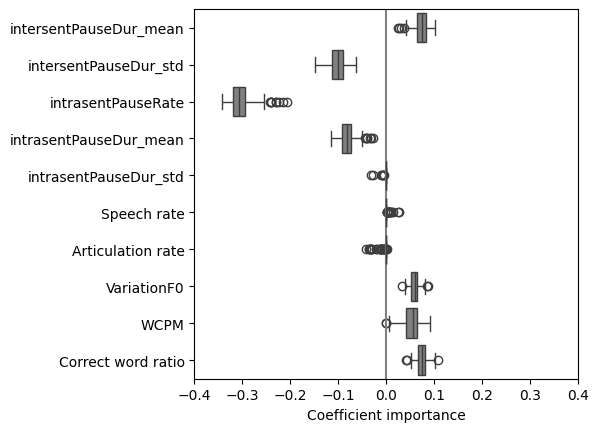

In [13]:
# Create the model, use default values for alpha and l1_ratio
model = make_pipeline(StandardScaler(), ElasticNet(alpha=0.01, l1_ratio=0.5))

cv_model = cross_validate(
    model,
    X,
    y,
    cv=RepeatedKFold(n_splits=10, n_repeats=10),
    return_estimator=True,
    n_jobs=2,
    scoring = ('r2', 'explained_variance', 'neg_mean_squared_error')
)

print('mean r2', np.mean(cv_model['test_r2']))
print('mean explained variance', np.mean(cv_model['test_explained_variance']) )
print('neg mean squared error', np.mean(cv_model['test_neg_mean_squared_error']) )
# Sklearn optimizes the evaluation metrics (higher is better). MSE is by default "lower is better".
# To deal with this discrepancy, Sklearn uses the negative MSE: -MSE.
# -MSE = -0.4 is equivalent to MSE=0.4

# For each fold, a model is trained on X_train. This model is called the "estimator"
coefs2 = pd.DataFrame(
    [model[1].coef_ for model in cv_model["estimator"]],
    columns=[x for x in X.columns],
)

# plt.figure(figsize=(9, 7))
sns.boxplot(data=coefs2, orient="h", color='grey', saturation=0.5)
plt.axvline(x=0, color=".5")
plt.xlabel("Coefficient importance")
# plt.title("Lasso regression coefficient importance")
plt.subplots_adjust(left=0.3)
plt.xticks(np.arange(-0.4, 0.5, 0.1))
plt.show()

Use ElasticNet CV to compute optimal values for alpha and l1_ratio

In [14]:
cv = RepeatedKFold(n_splits=10, n_repeats=10, random_state=42)

model_cv = make_pipeline(
    StandardScaler(),
    ElasticNetCV(
        l1_ratio=np.linspace(0.05, 1.0, 20),   # 0 = Ridge, 1 = Lasso
        alphas=np.logspace(-4, 2, 50),        # wide but reasonable range
        cv=cv,
        n_jobs=2,
        max_iter=10000
    )
)

model_cv.fit(X, y)

elasticnet = model_cv.named_steps["elasticnetcv"]

print("Optimal alpha:", elasticnet.alpha_)
print("Optimal l1_ratio:", elasticnet.l1_ratio_)


Optimal alpha: 0.006866488450042998
Optimal l1_ratio: 0.85


ElasticNet regression with most optimal parameters

mean r2 0.6152051805708205
mean explained variance 0.669782650020162
neg mean squared error -0.07313824745325319


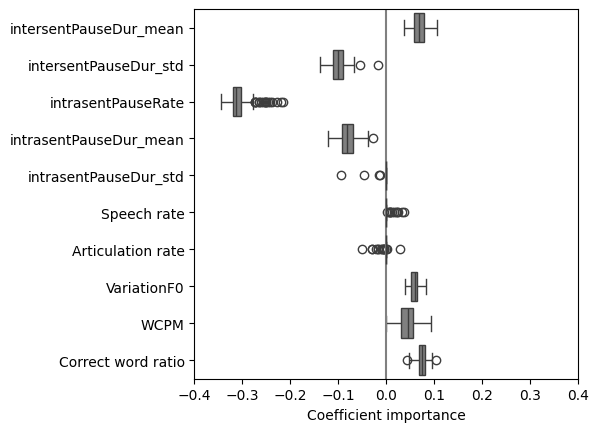

In [15]:
# Create the model
# model = make_pipeline(StandardScaler(), Lasso(alpha=0.1))
model = make_pipeline(StandardScaler(), ElasticNet(alpha=elasticnet.alpha_, l1_ratio=elasticnet.l1_ratio_))

cv_model = cross_validate(
    model,
    X,
    y,
    cv=RepeatedKFold(n_splits=10, n_repeats=10),
    return_estimator=True,
    n_jobs=2,
    scoring = ('r2', 'explained_variance', 'neg_mean_squared_error')
)

print('mean r2', np.mean(cv_model['test_r2']))
print('mean explained variance', np.mean(cv_model['test_explained_variance']) )
print('neg mean squared error', np.mean(cv_model['test_neg_mean_squared_error']) )

# For each fold, a model is trained on X_train. This model is called the "estimator"
coefs2 = pd.DataFrame(
    [model[1].coef_ for model in cv_model["estimator"]],
    columns=[x for x in X.columns],
)

# plt.figure(figsize=(9, 7))
sns.boxplot(data=coefs2, orient="h", color='grey', saturation=0.5)
plt.axvline(x=0, color=".5")
plt.xlabel("Coefficient importance")
# plt.title("Lasso regression coefficient importance")
plt.subplots_adjust(left=0.3)
plt.xticks(np.arange(-0.4, 0.5, 0.1))
plt.show()

<Axes: >

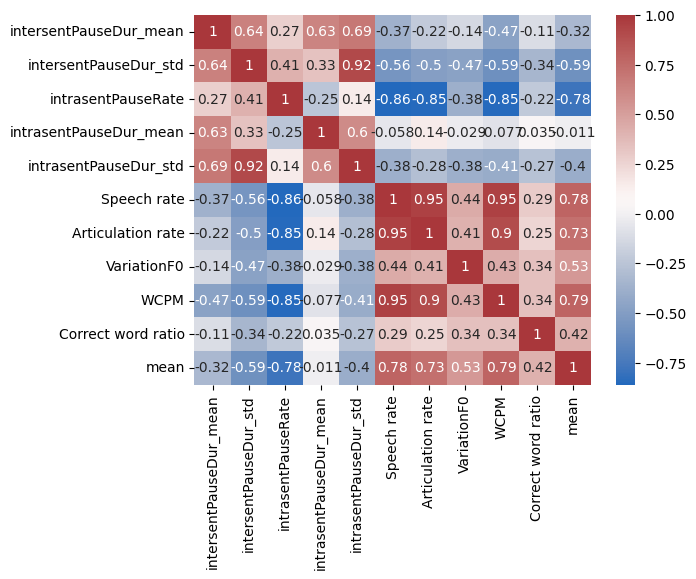

In [16]:
sns.heatmap(combiDF.corr(), cmap='vlag', annot=True)